In [26]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

In [27]:
# Define TORCH_VERSION for PyG dependencies
TORCH_VERSION = torch.__version__.split('+')[0]

# The following installations are typically handled by `torch_geometric`.
# Since `torch_geometric` was already installed, these explicit installs are redundant.
# !pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH_VERSION}.html
# !pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH_VERSION}.html

print("torch-scatter and torch-sparse installations are handled by torch_geometric.")

torch-scatter and torch-sparse installations are handled by torch_geometric.


In [28]:
df = pd.read_csv('../../data/data/processed/fdemand.csv')

In [29]:
df['end_time'] = pd.to_datetime({
    'year': df['end_year'],
    'month': df['end_month'],
    'day': df['end_day'],
    'hour': df['end_hour'],
    'minute': df['end_minute']
})
df['start_time'] = pd.to_datetime({
    'year': df['st_year'],
    'month': df['st_month'],
    'day': df['st_day'],
    'hour': df['st_hour'],
    'minute': df['st_minute']
})

Filtering data to include only entries from '2023-01-01' onwards.

In [30]:
df = df[df['start_time'] >= '2023-01-01']
print(f"DataFrame shape after date filtering: {df.shape}")

DataFrame shape after date filtering: (3785217, 53)


make sure that the data doesn't include station 3000 as either start or end station

In [31]:
data = df[(df['start_station'] != 3000) | (df['end_station'] != 3000)]

In [32]:
df = df[(df['start_station'] != 3000) & (df['end_station'] != 3000)]
print(f"DataFrame shape after station filtering: {df.shape}")

DataFrame shape after station filtering: (3737313, 53)


In [33]:
data.head()

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,end_lon,dist_km,avg_wind,precip,snow,snow_ground,max_temp,min_temp,end_time,start_time
2495345,70,3063,3063,365,2023,1,1,0,0,2023,...,-75.16980,0.000000,7.61,0.0,0.0,0.0,57,39,2023-01-01 01:10:00,2023-01-01 00:00:00
2495346,17,3190,3207,30,2023,1,1,0,5,2023,...,-75.19200,NaN,7.61,0.0,0.0,0.0,57,39,2023-01-01 00:22:00,2023-01-01 00:05:00
2495347,11,3182,3102,30,2023,1,1,0,6,2023,...,-75.17952,NaN,7.61,0.0,0.0,0.0,57,39,2023-01-01 00:17:00,2023-01-01 00:06:00
2495348,27,3046,3112,30,2023,1,1,0,9,2023,...,-75.21825,NaN,7.61,0.0,0.0,0.0,57,39,2023-01-01 00:36:00,2023-01-01 00:09:00
2495349,13,3026,3041,30,2023,1,1,0,10,2023,...,-75.13546,3.086574,7.61,0.0,0.0,0.0,57,39,2023-01-01 00:23:00,2023-01-01 00:10:00


**FOR NEXT TIME: MAKE SURE THAT THE DATA IS CUT FOR  2023-01-1 AND CORRECT TIME SERIES SPLIT IS USED!**

In [34]:
# --- 2. Prepare Datetime Columns ---
# Ensure the 'df' DataFrame has datetime columns for time-series analysis
df['end_time'] = pd.to_datetime({
    'year': df['end_year'],
    'month': df['end_month'],
    'day': df['end_day'],
    'hour': df['end_hour'],
    'minute': df['end_minute']
})
df['start_time'] = pd.to_datetime({
    'year': df['st_year'],
    'month': df['st_month'],
    'day': df['st_day'],
    'hour': df['st_hour'],
    'minute': df['st_minute']
})

In [35]:
# --- 3. Identify Stations and Map IDs ---
# Get all unique stations to serve as nodes in our graph
all_stations = pd.concat([df['start_station'], df['end_station']]).unique()
station_to_idx = {station_id: idx for idx, station_id in enumerate(all_stations)}
idx_to_station = {idx: station_id for station_id, idx in station_to_idx.items()}
num_nodes = len(all_stations)

print(f"Total unique stations identified: {num_nodes}")

Total unique stations identified: 332


In [36]:
# --- 4. Extract Node Features (Latitude and Longitude) ---
# Collect unique station coordinates for node features.
# Taking the first occurrence of lat/lon for each station_id.
station_lat_lon = pd.concat([
    df[['start_station', 'st_lat', 'st_lon']].rename(columns={'start_station': 'station_id', 'start_lat': 'latitude', 'start_lon': 'longitude'}),
    df[['end_station', 'end_lat', 'end_lon']].rename(columns={'end_station': 'station_id', 'end_lat': 'latitude', 'end_lon': 'longitude'})
]).drop_duplicates(subset=['station_id']).set_index('station_id')

node_features = []
for station_id in all_stations:
    if station_id in station_lat_lon.index:
        node_features.append(station_lat_lon.loc[station_id][['latitude', 'longitude']].values)
    else:
        # Fallback if a station somehow doesn't have coordinates (should ideally not happen)
        node_features.append([0.0, 0.0]) # Placeholder coordinates
node_features_tensor = torch.tensor(node_features, dtype=torch.float)

print(f"Node features tensor shape: {node_features_tensor.shape}")

Node features tensor shape: torch.Size([332, 2])


In [37]:
# --- 5. Construct Graph Edges (Static Graph) ---
# Create edges based on all observed trips between stations throughout the dataset.
# We assume an undirected graph for simplicity by adding reverse edges.
edges_df = df[['start_station', 'end_station']].drop_duplicates()
edge_index_list = []
for _, row in edges_df.iterrows():
    src = station_to_idx[row['start_station']]
    dst = station_to_idx[row['end_station']]
    edge_index_list.append([src, dst])
    edge_index_list.append([dst, src]) # Add reverse edge for undirected graph

edge_index_tensor = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()

print(f"Edge index tensor shape: {edge_index_tensor.shape}")

Edge index tensor shape: torch.Size([2, 144206])


In [38]:
# --- 6. Aggregate Hourly Arrivals ---

# Ensure datetime
df['end_time'] = pd.to_datetime(df['end_time'])

# Create a complete hourly timeline
all_hours = pd.date_range(
    start=df['end_time'].min().floor('h'),
    end=df['end_time'].max().ceil('h'),
    freq='h'
)

# Count arrivals per station per hour
hourly_arrivals_raw = (
    df.groupby([pd.Grouper(key='end_time', freq='h'), 'end_station'])
      .size()
      .reset_index(name='arrivals')
)

# Fill in missing station-hour combinations with 0 arrivals
multi_index = pd.MultiIndex.from_product(
    [all_hours, all_stations],
    names=['end_time', 'end_station']
)

full_hourly_arrivals = (
    hourly_arrivals_raw
    .set_index(['end_time', 'end_station'])
    .reindex(multi_index, fill_value=0)
    .reset_index()
)

# Map station IDs to node indices
full_hourly_arrivals['end_station_idx'] = (
    full_hourly_arrivals['end_station'].map(station_to_idx)
)

print(f"Aggregated hourly arrivals for all stations and hours: {len(full_hourly_arrivals):,} entries")

Aggregated hourly arrivals for all stations and hours: 9,450,712 entries


In [39]:
# --- 7. Transform into Time-Series Matrix ---
# Create a matrix where each row is a time step and columns are stations (or vice versa).
# arrivals_matrix[time_step_idx, station_idx] = num_arrivals
time_steps = len(all_hours)
arrivals_matrix = torch.zeros((time_steps, num_nodes), dtype=torch.float)

# Optimized approach: Use vectorized operations instead of iterrows()
# Create a Series that maps 'end_time' values to their integer locations (indices)
# in the 'all_hours' DatetimeIndex. This ensures `get_loc` is not called in a loop.
time_to_idx_map = pd.Series(range(len(all_hours)), index=all_hours)

# Map the 'end_time' column from full_hourly_arrivals to get the time_idx
# This creates a new column 'time_idx' in a vectorized manner
full_hourly_arrivals['time_idx'] = full_hourly_arrivals['end_time'].map(time_to_idx_map)

# Get the indices and values as tensors for direct assignment
time_indices = torch.tensor(full_hourly_arrivals['time_idx'].values, dtype=torch.long)
station_indices = torch.tensor(full_hourly_arrivals['end_station_idx'].values, dtype=torch.long)
arrival_values = torch.tensor(full_hourly_arrivals['arrivals'].values, dtype=torch.float)

# Populate the arrivals_matrix using advanced indexing (vectorized assignment)
arrivals_matrix[time_indices, station_indices] = arrival_values

print(f"Arrivals matrix shape: {arrivals_matrix.shape} (time_steps, num_nodes)")

Arrivals matrix shape: torch.Size([28466, 332]) (time_steps, num_nodes)


now to build the gnn

In [40]:
# --- 8. Create GNN Dataset of Graph Snapshots ---
# Each data sample will contain a graph structure and time-varying node features.
# Node features (x) will be a sequence of past arrivals for each station.
# Target (y) will be future arrivals for each station.

input_sequence_length = 3  # Use 3 past hours of arrivals as input features
output_sequence_length = 1 # Predict arrivals for the next 1 hour

data_list = []
# Iterate through time to create input-output pairs
for t in range(input_sequence_length, time_steps - output_sequence_length + 1):
    # Node features: arrivals from t-input_sequence_length to t-1~~~~
    x_node_features = arrivals_matrix[t - input_sequence_length : t, :].T

    # Target: arrivals from t to t+output_sequence_length-1
    y_target = arrivals_matrix[t : t + output_sequence_length, :].T

    # Create a PyTorch Geometric Data object
    # x: node features, edge_index: graph connectivity, y: target values
    data_sample = Data(x=x_node_features, edge_index=edge_index_tensor, y=y_target)
    data_list.append(data_sample)

In [41]:
# Split into training and test sets (time-series split)
# Define the end date for the training set and the start date for the test set
train_end_date = pd.Timestamp('2024-12-13 23:00:00')
test_start_date = pd.Timestamp('2025-01-01 00:00:00')

# Find the index in `all_hours` that corresponds to the last hour of the training data's target
# We use `searchsorted(side='right') - 1` to find the index of the last element less than or equal to `train_end_date`.
train_end_time_idx_in_all_hours = all_hours.searchsorted(train_end_date, side='right') - 1

# Find the index in `all_hours` that corresponds to the first hour of the test data's target
# We use `searchsorted(side='left')` to find the index of the first element greater than or equal to `test_start_date`.
test_start_time_idx_in_all_hours = all_hours.searchsorted(test_start_date, side='left')

# Calculate the split indices for `data_list`.
# A sample `data_list[k]` has its target `y` starting at `all_hours[k + input_sequence_length]`.
# For training, we want `all_hours[k + input_sequence_length]` <= `train_end_time_idx_in_all_hours`.
# This means `k` <= `train_end_time_idx_in_all_hours - input_sequence_length`.
# So, `train_split_index` is the first index *not* included in the training set.
train_split_index = train_end_time_idx_in_all_hours - input_sequence_length + 1

# For testing, we want `all_hours[k + input_sequence_length]` >= `test_start_time_idx_in_all_hours`.
# This means `k` >= `test_start_time_idx_in_all_hours - input_sequence_length`.
# So, `test_start_data_list_idx` is the first index included in the test set.
test_start_data_list_idx = test_start_time_idx_in_all_hours - input_sequence_length

# Ensure calculated indices are within the valid range of `data_list` indices
train_split_index = max(0, min(train_split_index, len(data_list)))
test_start_data_list_idx = max(train_split_index, min(test_start_data_list_idx, len(data_list)))

# Perform the time-series split
train_dataset = data_list[:train_split_index]
test_dataset = data_list[test_start_data_list_idx:]

print(f"Train dataset will include targets up to: {all_hours[train_end_time_idx_in_all_hours]}")
print(f"Test dataset will include targets from: {all_hours[test_start_time_idx_in_all_hours]}")
print(f"Number of GNN training samples: {len(train_dataset)}")
print(f"Number of GNN test samples: {len(test_dataset)}")

Train dataset will include targets up to: 2024-12-13 23:00:00
Test dataset will include targets from: 2025-01-01 00:00:00
Number of GNN training samples: 17109
Number of GNN test samples: 10922


In [42]:
# --- 9. Define GNN Model ---
# A simple Graph Convolutional Network (GCN) for predicting node-level features (arrivals).
class GNNPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNNPredictor, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [43]:
# Model parameters
in_channels = input_sequence_length  # Input features per node (e.g., 3 past hourly arrivals)
hidden_channels = 16                 # Number of hidden units in the GCN layer
out_channels = output_sequence_length # Output features per node (e.g., 1 future hourly arrival)

model = GNNPredictor(in_channels, hidden_channels, out_channels)

print(f"GNN Model defined: {model}")

GNN Model defined: GNNPredictor(
  (conv1): GCNConv(3, 16)
  (conv2): GCNConv(16, 1)
)


In [44]:
# --- 10. Set up Training & Testing (Placeholder) ---
# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.5)
criterion = nn.MSELoss() # Mean Squared Error for regression task

# Placeholder for a training function
def train_epoch():
    model.train()
    total_loss = 0
    for data_batch in train_dataset:
        optimizer.zero_grad()
        out = model(data_batch.x, data_batch.edge_index)
        loss = criterion(out, data_batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_dataset)

# Placeholder for a testing/evaluation function
def evaluate(dataset):
    model.eval()
    total_loss = 0
    with torch.no_grad(): # Disable gradient calculation for inference
        for data_batch in dataset:
            out = model(data_batch.x, data_batch.edge_index)
            loss = criterion(out, data_batch.y)
            total_loss += loss.item()
    return total_loss / len(dataset)

In [45]:
# Calculate the maximum arrival value for normalization
# This assumes 'arrivals_matrix' is available from previous cells.
# If arrivals_matrix is all zeros, max_arrival_value will be 0. Handle this to avoid division by zero.
max_arrival_value = arrivals_matrix.max()
if max_arrival_value == 0:
    print("Warning: All arrival values are zero. Normalization cannot be applied effectively.")
    # In this case, use 1.0 as normalization factor to avoid division by zero without scaling.
    normalization_factor = 1.0
else:
    normalization_factor = max_arrival_value

# Redefine the training function to include normalization
def train_epoch():
    model.train()
    total_loss = 0
    for data_batch in train_dataset:
        optimizer.zero_grad()
        # Normalize input features and target
        normalized_x = data_batch.x / normalization_factor
        normalized_y = data_batch.y / normalization_factor

        out = model(normalized_x, data_batch.edge_index)
        loss = criterion(out, normalized_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_dataset)

# Redefine the testing/evaluation function to include normalization
def evaluate(dataset):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data_batch in dataset:
            # Normalize input features and target
            normalized_x = data_batch.x / normalization_factor
            normalized_y = data_batch.y / normalization_factor

            out = model(normalized_x, data_batch.edge_index)
            loss = criterion(out, normalized_y)
            total_loss += loss.item()
    return total_loss / len(dataset)




In [46]:
num_epochs = 10 # Increased epochs to allow for more learning
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    test_loss = evaluate(test_dataset)
    if epoch % 2 == 0 or epoch == 1: # Print less frequently for more epochs
        print(f'Epoch: {epoch:02d}, Train Loss: {train_loss:.9f}, Test Loss: {test_loss:.9f}')

Epoch: 01, Train Loss: 0.001148118, Test Loss: 0.000705590
Epoch: 02, Train Loss: 0.000867225, Test Loss: 0.000705590
Epoch: 04, Train Loss: 0.000867225, Test Loss: 0.000705590
Epoch: 06, Train Loss: 0.000867225, Test Loss: 0.000705590
Epoch: 08, Train Loss: 0.000867225, Test Loss: 0.000705590
Epoch: 10, Train Loss: 0.000867225, Test Loss: 0.000705590


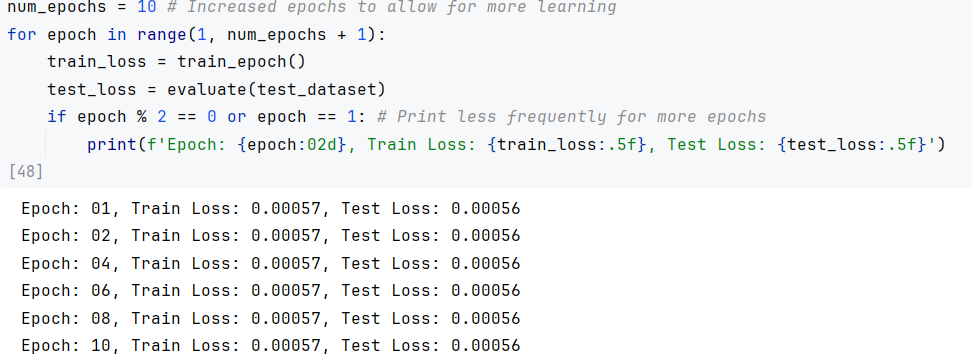

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_prediction_metrics(dataset, normalization_factor):
    model.eval()
    all_predictions = []
    all_actuals = []

    with torch.no_grad():
        for data_batch in dataset:
            # Normalize input features for prediction
            normalized_x = data_batch.x / normalization_factor

            out = model(normalized_x, data_batch.edge_index)

            # Denormalize predictions and actuals before collecting
            denormalized_predictions = out * normalization_factor
            denormalized_actuals = data_batch.y * normalization_factor

            all_predictions.append(denormalized_predictions.cpu().numpy())
            all_actuals.append(denormalized_actuals.cpu().numpy())

    # Concatenate all predictions and actuals
    predictions_np = np.concatenate(all_predictions, axis=1).flatten() # Flatten because y is [num_nodes, 1]
    actuals_np = np.concatenate(all_actuals, axis=1).flatten()       # Flatten because y is [num_nodes, 1]

    # Calculate metrics
    mae = mean_absolute_error(actuals_np, predictions_np)
    mse = mean_squared_error(actuals_np, predictions_np)
    rmse = np.sqrt(mse)

    print(f"\n--- Prediction Metrics on Test Set ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Call the evaluation function
evaluate_prediction_metrics(test_dataset, normalization_factor)


--- Prediction Metrics on Test Set ---
Mean Absolute Error (MAE): 15.8455
Mean Squared Error (MSE): 1695.4360
Root Mean Squared Error (RMSE): 41.1757


Visualizing predictions vs. actuals for a few stations over time can provide a qualitative understanding of the model's performance.

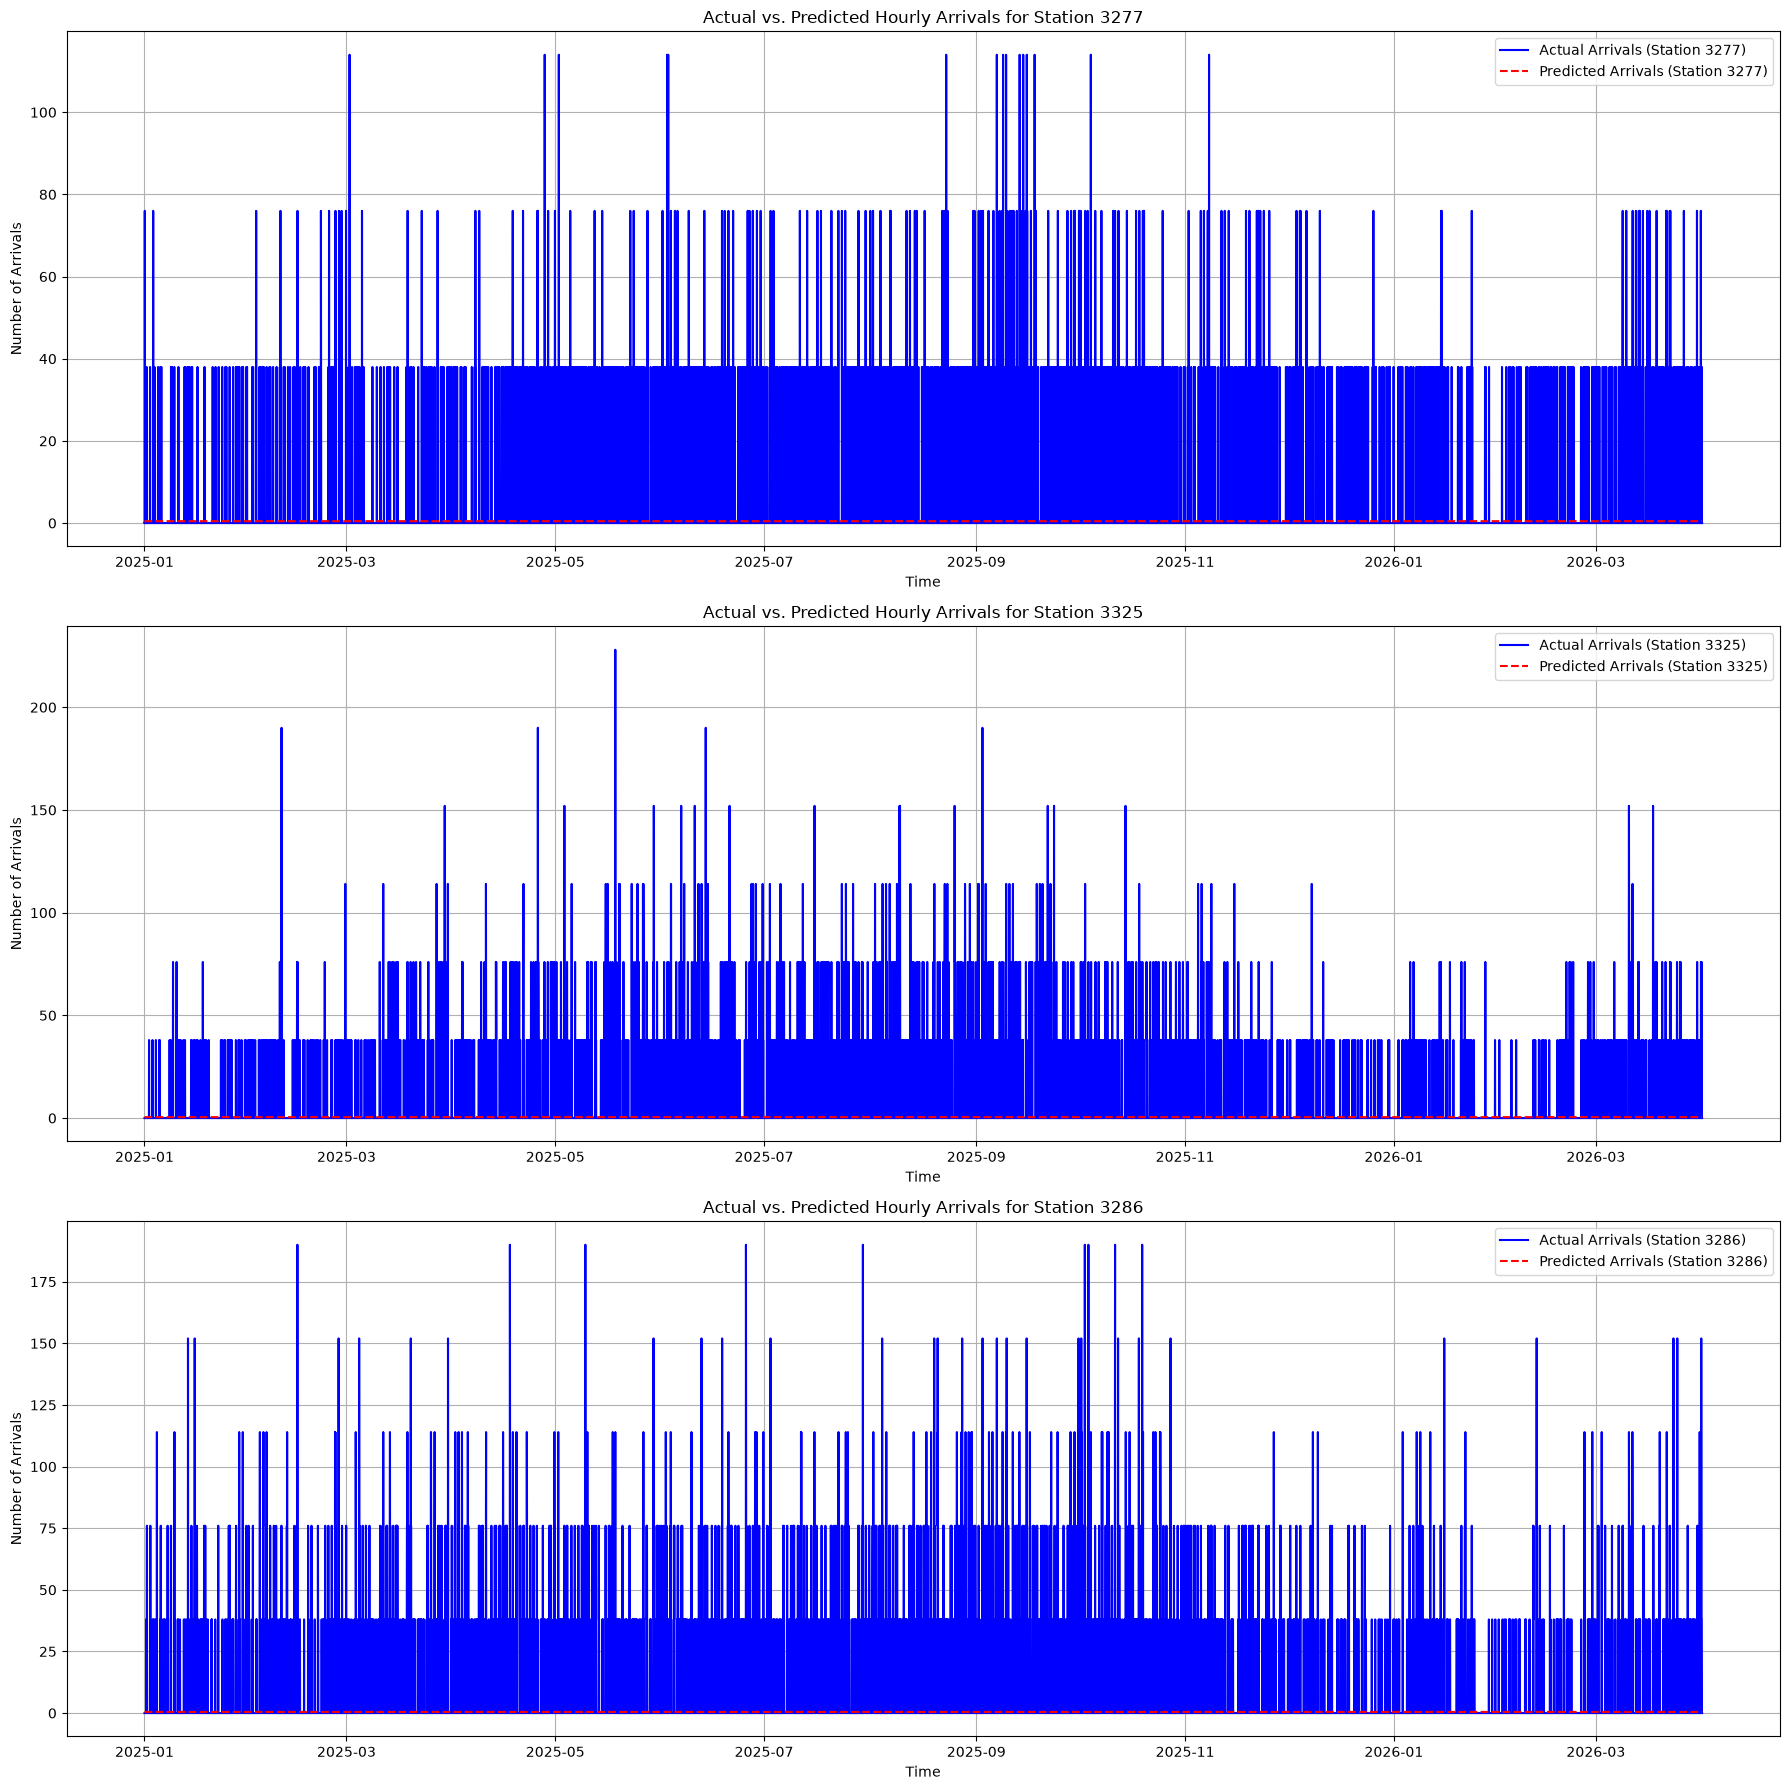

In [48]:
import matplotlib.pyplot as plt
import random

# Collect all denormalized predictions and actuals from the test set
model.eval()
all_predictions_denorm = []
all_actuals_denorm = []

with torch.no_grad():
    for data_batch in test_dataset:
        normalized_x = data_batch.x / normalization_factor
        out = model(normalized_x, data_batch.edge_index)
        all_predictions_denorm.append((out * normalization_factor).cpu().numpy())
        all_actuals_denorm.append((data_batch.y * normalization_factor).cpu().numpy())

# Stack them to get (num_test_samples, num_nodes, output_sequence_length)
predictions_stacked = np.stack(all_predictions_denorm)
actuals_stacked = np.stack(all_actuals_denorm)

# Reshape if output_sequence_length is 1 to (num_test_samples, num_nodes)
if output_sequence_length == 1:
    predictions_stacked = predictions_stacked.squeeze(axis=2)
    actuals_stacked = actuals_stacked.squeeze(axis=2)

# Determine the time range for the test set targets
# The target `y` of `test_dataset[k]` corresponds to time `all_hours[test_start_data_list_idx + k + input_sequence_length]`
start_time_idx = test_start_data_list_idx + input_sequence_length
end_time_idx = start_time_idx + len(test_dataset)

test_time_stamps = all_hours[start_time_idx:end_time_idx]

# Select a few random stations to plot
num_stations_to_plot = 3
random_station_indices = random.sample(range(num_nodes), num_stations_to_plot)

plt.figure(figsize=(18, 6 * num_stations_to_plot))

for i, station_idx in enumerate(random_station_indices):
    station_id = idx_to_station[station_idx] # Convert index back to original station ID

    plt.subplot(num_stations_to_plot, 1, i + 1)
    plt.plot(test_time_stamps, actuals_stacked[:, station_idx], label=f'Actual Arrivals (Station {station_id})', color='blue')
    plt.plot(test_time_stamps, predictions_stacked[:, station_idx], label=f'Predicted Arrivals (Station {station_id})', color='red', linestyle='--')
    plt.title(f'Actual vs. Predicted Hourly Arrivals for Station {station_id}')
    plt.xlabel('Time')
    plt.ylabel('Number of Arrivals')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

plt.show()


Descriptive statistics of actual arrivals in the test set:
count    3.626104e+06
mean     1.558919e+01
std      3.829792e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.444000e+03
dtype: float64


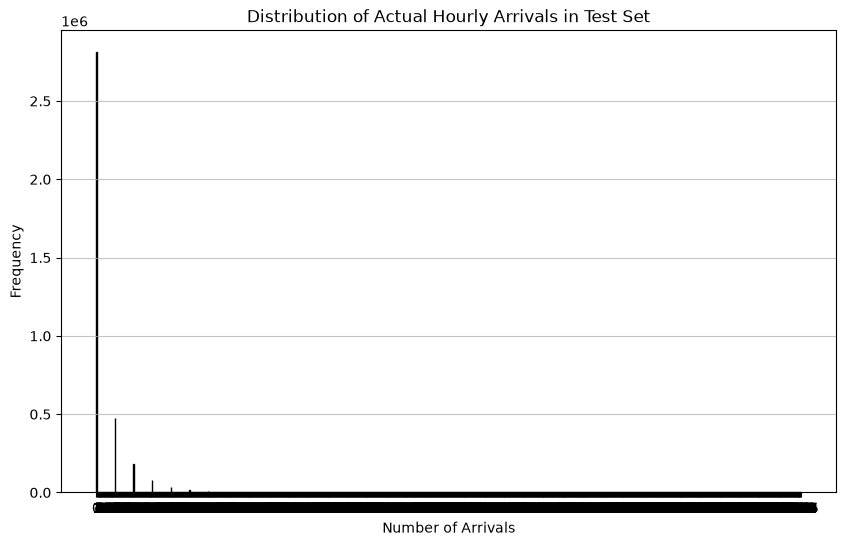

In [49]:
# Flatten all actuals from the test dataset for analysis
all_actuals_flat = np.concatenate(all_actuals_denorm, axis=1).flatten()

# Get descriptive statistics
print("\nDescriptive statistics of actual arrivals in the test set:")
print(pd.Series(all_actuals_flat).describe())

# Plot a histogram to visualize the distribution of actual arrivals
plt.figure(figsize=(10, 6))
plt.hist(all_actuals_flat, bins=range(int(max(all_actuals_flat)) + 2), edgecolor='black')
plt.title('Distribution of Actual Hourly Arrivals in Test Set')
plt.xlabel('Number of Arrivals')
plt.ylabel('Frequency')
plt.xticks(range(int(max(all_actuals_flat)) + 2))
plt.grid(axis='y', alpha=0.75)
plt.show()